# MonteCarlo for trippel-integral

La oss forsøke å beregne

$$
I = \int_{0}^{1} \int_{0}^{x^{2}} \int_{0}^{y^{2}} 1 \, dz \, dy \, dx
$$

ved hjelp av Monte Carlo tilnærming.

In [23]:
import numpy as np

# Antall simuleringer
N = 10

# Generer tilfeldige punkter i [0,1]^3
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

# Sjekk om punktene er inne i området
inside = (y <= x**2) & (z <= y**2)

# Estimer volumet = andel punkter inne * volumboksen (1)
I_est = np.mean(inside)

#print(len(inside))
#print(inside)
#print(np.sum(inside))
print("Monte Carlo estimat:", I_est)

Monte Carlo estimat: 0.1


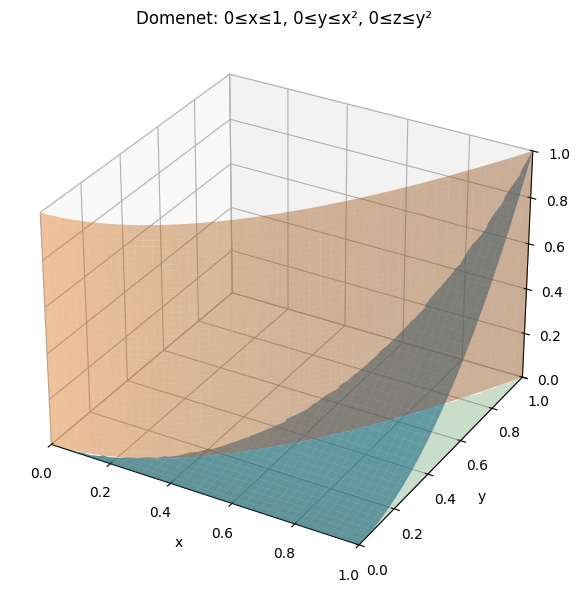

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- figur/akser ---
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# --- rutenett for (x,y) ---
x = np.linspace(0, 1, 120)
y = np.linspace(0, 1, 120)
X, Y = np.meshgrid(x, y)

# Tak: z = y^2, men bare der y <= x^2 (ellers ligger det utenfor domenet)
Z = Y**2
mask = (Y <= X**2)
Z_roof = np.where(mask, Z, np.nan)
ax.plot_surface(X, Y, Z_roof, alpha=0.6, edgecolor='none')

# Vegg: y = x^2, for 0 <= x <= 1 og 0 <= z <= 1
xw = np.linspace(0, 1, 200)
zw = np.linspace(0, 1, 80)
Xw, Zw = np.meshgrid(xw, zw)
Yw = Xw**2
ax.plot_surface(Xw, Yw, Zw, alpha=0.4, edgecolor='none')

# Gulv (projeksjon av domenet i z=0): 0 <= y <= x^2
Z0 = np.zeros_like(X)
Y0 = np.where(mask, Y, np.nan)
ax.plot_surface(X, Y0, Z0, alpha=0.2, edgecolor='none')

# Akseoppsett
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Domenet: 0≤x≤1, 0≤y≤x², 0≤z≤y²')

plt.tight_layout()
plt.show()

# Feil-estimat
(ikke pensum)

En måte å estimere feilen på er å se på standardavviket:

In [7]:
import numpy as np

N = 1_000_000  

x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

inside = (y <= x**2) & (z <= y**2)

I_est = np.mean(inside)

# Standard error (feilestimat)
stderr = np.sqrt(I_est * (1 - I_est) / N)

print("Monte Carlo estimat:", I_est)
print("Feilestimat (standard error): ±", stderr)

Monte Carlo estimat: 0.047736
Feilestimat (standard error): ± 0.0002132071159788059


Eventuelt, om man heller ønsker et konfidensintervall:

In [8]:
ci_low = I_est - 1.96*stderr
ci_high = I_est + 1.96*stderr
print(f"95% konfidensintervall: [{ci_low}, {ci_high}]")

95% konfidensintervall: [0.04731811405268154, 0.04815388594731846]
